# 🚒 London Fire Brigade — Préprocessing des données
**Liora Data Analyst Bootcamp | Les Mines PSL | Février 2026**
**Auteur : Gaëtan Seynave**

---

## Contexte
Ce notebook couvre l'intégralité du pipeline de préparation des données du projet LFB :
chargement des fichiers bruts, harmonisation, nettoyage, enrichissement et export
vers les fichiers `.parquet` utilisés par le tableau de bord Power BI.

**Sources :** [London Data Store](https://data.london.gov.uk/) — données publiques LFB
**Période analysée :** 1er janvier 2021 – 31 décembre 2025 (post-COVID, années pleines)

---

## Structure du notebook

| Étape | Contenu |
|---|---|
| 0 | Imports & fonctions utilitaires |
| 1 | Chargement et conversion en Parquet |
| 2 | Incidents — analyse, harmonisation, concaténation |
| 3 | Mobilisations — analyse, harmonisation, concaténation |
| 4 | Restriction temporelle 2021–2025 |
| 5 | Traitement des NaN — Incidents |
| 6 | Traitement des NaN — Mobilisations |
| 7 | Enrichissement météo (API Open-Meteo) |
| 8 | Exports finaux |

## 0. Imports & fonctions utilitaires

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Transformer
import openmeteo_requests
import requests_cache
from retry_requests import retry

%matplotlib inline
pd.set_option('display.max_columns', None)

### Fonctions utilitaires
Trois fonctions réutilisables pour l'exploration et la comparaison des DataFrames.

In [10]:
def resume_df(df):
    """Résume les caractéristiques principales d'un DataFrame :
    type, nb valeurs uniques, nb et % de valeurs nulles."""
    resume = pd.DataFrame({
        "type": df.dtypes,
        "nb_valeurs_uniques": df.nunique(),
        "nb_valeurs_nulles": df.isna().sum(),
        "pourcentage_null": round((df.isna().sum() / len(df)) * 100, 2)
    })
    return resume.sort_values("nb_valeurs_uniques")


def compare_columns(dfs: dict):
    """Compare les noms de colonnes entre plusieurs DataFrames.
    Retourne les colonnes communes et les différences."""
    cols = {k: set(v.columns) for k, v in dfs.items()}
    common = None
    union = set()
    for col_set in cols.values():
        common = col_set.copy() if common is None else common & col_set
        union |= col_set
    differences = {
        k: {
            "colonnes_specifiques": cols[k] - common,
            "colonnes_manquantes": union - cols[k]
        }
        for k in dfs
    }
    return {"colonnes_communes": common, "colonnes_differentes": differences}


def compare_dtypes(dfs: dict):
    """Compare les types de données des colonnes communes entre plusieurs DataFrames.
    Affiche uniquement les colonnes présentant des différences."""
    dtype_table = pd.DataFrame({k: v.dtypes.astype(str) for k, v in dfs.items()})
    diffs = dtype_table[dtype_table.nunique(axis=1) > 1].sort_index()
    print(f"Colonnes avec dtypes différents : {diffs.shape[0]}")
    return diffs


def iqr_outlier_detection(df, feature, threshold=1.5):
    """Détecte les outliers d'une colonne via la méthode IQR.

    Args:
        df: DataFrame source
        feature: nom de la colonne à analyser
        threshold: multiplicateur IQR (défaut 1.5)
    Returns:
        DataFrame des lignes identifiées comme outliers
    """
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    proportion = (len(outliers) / len(df)) * 100
    stats = pd.DataFrame({
        "Proportion d'outliers (%)": [round(proportion, 2)],
        "Nombre d'outliers": [len(outliers)]
    })
    print(f"Statistiques pour la colonne : {feature}")
    display(stats)
    return outliers

## 1. Chargement et conversion en Parquet

Les fichiers sources (`.csv` et `.xlsx`) sont convertis en `.parquet` pour optimiser
les performances de lecture (poids réduit, types préservés, calculs plus rapides).

> ⚠️ **Données sources non incluses dans ce repository** (fichiers > 500 Mo).
> Téléchargeables gratuitement sur le [London Data Store](https://data.london.gov.uk/) :
> - [Incident Records](https://data.london.gov.uk/dataset/london-fire-brigade-incident-records-em8xy/)
> - [Mobilisation Records](https://data.london.gov.uk/dataset/london-fire-brigade-mobilisation-records-24r65/)
>
> Placer les fichiers dans le dossier `data/raw/` avant d'exécuter cette cellule.

In [14]:
dossier_source = os.path.join(os.getcwd(), '..', 'data', 'original')

dossier_destination = os.path.join(os.getcwd(), '..', 'data', 'raw')

# Vérifier si les dossiers existent pour éviter d'autres erreurs
if not os.path.exists(dossier_source):
    print(f"❌ Erreur : Le dossier source n'existe pas : {dossier_source}")
else:
    fichiers_a_convertir = [
        'LFB Incident data from 2009 - 2017.csv',
        'LFB Incident data from 2018 - 2023.xlsx',
        'LFB Incident data from 2024 onwards.xlsx',
        'LFB Mobilisation data from January 2009 - 2014.xlsx',
        'LFB Mobilisation data from 2015 - 2020.xlsx',
        'LFB Mobilisation data from 2021 - 2024.csv',
        'LFB Mobilisation data from 2025.csv'
    ]

    for fichier in fichiers_a_convertir:
        chemin_complet = os.path.join(dossier_source, fichier)
        
        # Vérification si le fichier existe physiquement
        if not os.path.isfile(chemin_complet):
            print(f"⚠️ Fichier introuvable : {fichier} (Passage au suivant)")
            continue
            
        nouveau_nom = fichier.replace('.xlsx', '.parquet').replace('.csv', '.parquet')
        chemin_parquet = os.path.join(dossier_destination, nouveau_nom)
        
        print(f"Lecture : {fichier}...")
        
        if fichier.endswith('.xlsx'):
            df = pd.read_excel(chemin_complet)
        elif fichier.endswith('.csv'):
            df = pd.read_csv(chemin_complet, low_memory=False)
        
        # Conversion des colonnes objets en string pour éviter les erreurs Parquet
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str)
        
        df.to_parquet(chemin_parquet, index=False)
        print(f"✅ Sauvegardé dans raw : {nouveau_nom}\n")

    print("Toutes les conversions sont terminées.")

Lecture : LFB Incident data from 2009 - 2017.csv...
✅ Sauvegardé dans raw : LFB Incident data from 2009 - 2017.parquet

Lecture : LFB Incident data from 2018 - 2023.xlsx...
✅ Sauvegardé dans raw : LFB Incident data from 2018 - 2023.parquet

Lecture : LFB Incident data from 2024 onwards.xlsx...
✅ Sauvegardé dans raw : LFB Incident data from 2024 onwards.parquet

Lecture : LFB Mobilisation data from January 2009 - 2014.xlsx...
✅ Sauvegardé dans raw : LFB Mobilisation data from January 2009 - 2014.parquet

Lecture : LFB Mobilisation data from 2015 - 2020.xlsx...
✅ Sauvegardé dans raw : LFB Mobilisation data from 2015 - 2020.parquet

Lecture : LFB Mobilisation data from 2021 - 2024.csv...
✅ Sauvegardé dans raw : LFB Mobilisation data from 2021 - 2024.parquet

Lecture : LFB Mobilisation data from 2025.csv...
✅ Sauvegardé dans raw : LFB Mobilisation data from 2025.parquet

Toutes les conversions sont terminées.


## 2. Incidents — Analyse, harmonisation, concaténation

Les données incidents sont réparties sur **3 fichiers** couvrant 2009–2026.
Avant concaténation : vérification des colonnes et uniformisation des types.

In [16]:
dossier_raw = os.path.join(os.getcwd(), '..', 'data', 'raw')

# Lecture des fichiers Parquet avec le bon chemin
incident_1 = pd.read_parquet(os.path.join(dossier_raw, 'LFB Incident data from 2009 - 2017.parquet'))
incident_2 = pd.read_parquet(os.path.join(dossier_raw, 'LFB Incident data from 2018 - 2023.parquet'))
incident_3 = pd.read_parquet(os.path.join(dossier_raw, 'LFB Incident data from 2024 onwards.parquet'))

dfsinc = {"inc1": incident_1, "inc2": incident_2, "inc3": incident_3}

print("Fichiers chargés avec succès !")


Fichiers chargés avec succès !


### 2.1 Comparaison des colonnes

In [17]:
compare_columns(dfsinc)

{'colonnes_communes': {'AddressQualifier',
  'CalYear',
  'DateOfCall',
  'Easting_m',
  'Easting_rounded',
  'FRS',
  'FirstPumpArriving_AttendanceTime',
  'FirstPumpArriving_DeployedFromStation',
  'HourOfCall',
  'IncGeo_BoroughCode',
  'IncGeo_BoroughName',
  'IncGeo_WardCode',
  'IncGeo_WardName',
  'IncGeo_WardNameNew',
  'IncidentGroup',
  'IncidentNumber',
  'IncidentStationGround',
  'Latitude',
  'Longitude',
  'Northing_m',
  'Northing_rounded',
  'Notional Cost (£)',
  'NumCalls',
  'NumPumpsAttending',
  'NumStationsWithPumpsAttending',
  'Postcode_district',
  'Postcode_full',
  'ProperCase',
  'PropertyCategory',
  'PropertyType',
  'PumpCount',
  'PumpMinutesRounded',
  'SecondPumpArriving_AttendanceTime',
  'SecondPumpArriving_DeployedFromStation',
  'SpecialServiceType',
  'StopCodeDescription',
  'TimeOfCall',
  'UPRN',
  'USRN'},
 'colonnes_differentes': {'inc1': {'colonnes_specifiques': set(),
   'colonnes_manquantes': set()},
  'inc2': {'colonnes_specifiques': set

> ✅ Les 3 fichiers partagent exactement les mêmes colonnes — aucun ajustement nécessaire.

### 2.2 Uniformisation des types de données

In [18]:
compare_dtypes(dfsinc)

Colonnes avec dtypes différents : 3


,inc1,inc2,inc3
DateOfCall,str,datetime64[us],datetime64[us]
UPRN,float64,int64,int64
USRN,float64,int64,int64


> 3 colonnes présentent des types hétérogènes entre les fichiers → uniformisation ci-dessous.

In [19]:
incident_1['DateOfCall'] = pd.to_datetime(incident_1['DateOfCall'], format='%d-%b-%y')

for df in [incident_1, incident_2, incident_3]:
    df['UPRN'] = df['UPRN'].astype('Int64')
    df['USRN'] = df['USRN'].astype('Int64')

### 2.3 Concaténation

In [20]:
incident_complet = pd.concat([incident_1, incident_2, incident_3], ignore_index=True)
incident_complet = incident_complet.drop_duplicates()

incident_complet['IncidentWithMobilisation'] = (
    incident_complet['FirstPumpArriving_AttendanceTime'].notna().astype(int)
)

print(f"Dimensions du DataFrame incidents complet : {incident_complet.shape}")
incident_complet.head(3)

Dimensions du DataFrame incidents complet : (1942988, 40)


,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,AddressQualifier,Postcode_full,Postcode_district,UPRN,USRN,IncGeo_BoroughCode,IncGeo_BoroughName,ProperCase,IncGeo_WardCode,IncGeo_WardName,IncGeo_WardNameNew,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FRS,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls,IncidentWithMobilisation
0,235138081.00,2009-01-01,2009,00:00:37,0,Special Service,Special Service,RTC,Road Vehicle,Car,In street close to gazetteer location,SW11 4LB,SW11,<NA>,<NA>,E09000032,WANDSWORTH,Wandsworth,E05014010,Battersea Park,Battersea Park,528652.0,176830.0,528650,176850,51.475812,-0.148894,London,Battersea,319.0,Battersea,342.0,Clapham,2.0,2.0,2,60,255,1.0,1
1,1091.00,2009-01-01,2009,00:00:46,0,Special Service,Special Service,Assist other agencies,Outdoor,Lake/pond/reservoir,Open land/water - nearest gazetteer location,SE1 7SG,SE1,<NA>,<NA>,E09000022,LAMBETH,Lambeth,E05014118,Waterloo & South Bank,Waterloo & South Bank,530485.0,179007.0,530450,179050,51.494957,-0.121712,London,Lambeth,NaN,NaN,NaN,NaN,NaN,NaN,1,60,255,1.0,0
2,2091.00,2009-01-01,2009,00:03:00,0,Fire,Secondary Fire,NaN,Outdoor,Road surface/pavement,In street outside gazetteer location,N9 9EL,N9,<NA>,<NA>,E09000010,ENFIELD,Enfield,E05013682,Haselbury,Haselbury,533773.0,194492.0,533750,194450,51.633342,-0.068488,London,Edmonton,308.0,Edmonton,NaN,NaN,1.0,1.0,1,60,255,2.0,1


## 3. Mobilisations — Analyse, harmonisation, concaténation

Les données mobilisations sont réparties sur **4 fichiers** couvrant 2009–2025.

In [22]:
dossier_raw = os.path.join(os.getcwd(), '..', 'data', 'raw')

# Lecture des fichiers Parquet
mobilisation_1 = pd.read_parquet(os.path.join(dossier_raw, 'LFB Mobilisation data from January 2009 - 2014.parquet'))
mobilisation_2 = pd.read_parquet(os.path.join(dossier_raw, 'LFB Mobilisation data from 2015 - 2020.parquet'))
mobilisation_3 = pd.read_parquet(os.path.join(dossier_raw, 'LFB Mobilisation data from 2021 - 2024.parquet'))
mobilisation_4 = pd.read_parquet(os.path.join(dossier_raw, 'LFB Mobilisation data from 2025.parquet'))

dfsmob = {
    "mob1": mobilisation_1, 
    "mob2": mobilisation_2,
    "mob3": mobilisation_3, 
    "mob4": mobilisation_4
}

print("Fichiers de mobilisation chargés avec succès !")

Fichiers de mobilisation chargés avec succès !


In [23]:
compare_columns(dfsmob)

{'colonnes_communes': {'AttendanceTimeSeconds',
  'CalYear',
  'DateAndTimeArrived',
  'DateAndTimeLeft',
  'DateAndTimeMobile',
  'DateAndTimeMobilised',
  'DateAndTimeReturned',
  'DelayCodeId',
  'DelayCode_Description',
  'DeployedFromLocation',
  'DeployedFromStation_Code',
  'DeployedFromStation_Name',
  'HourOfCall',
  'IncidentNumber',
  'PerformanceReporting',
  'PlusCode_Code',
  'PlusCode_Description',
  'PumpOrder',
  'ResourceMobilisationId',
  'Resource_Code',
  'TravelTimeSeconds',
  'TurnoutTimeSeconds'},
 'colonnes_differentes': {'mob1': {'colonnes_specifiques': set(),
   'colonnes_manquantes': {'BoroughName', 'WardName'}},
  'mob2': {'colonnes_specifiques': set(),
   'colonnes_manquantes': {'BoroughName', 'WardName'}},
  'mob3': {'colonnes_specifiques': {'BoroughName', 'WardName'},
   'colonnes_manquantes': set()},
  'mob4': {'colonnes_specifiques': {'BoroughName', 'WardName'},
   'colonnes_manquantes': set()}}}

In [24]:
compare_dtypes(dfsmob)

Colonnes avec dtypes différents : 6


,mob1,mob2,mob3,mob4
DateAndTimeArrived,datetime64[us],datetime64[us],str,str
DateAndTimeLeft,datetime64[us],datetime64[us],str,str
DateAndTimeMobile,datetime64[us],datetime64[us],str,str
DateAndTimeMobilised,datetime64[us],datetime64[us],str,str
DateAndTimeReturned,datetime64[us],datetime64[us],float64,str
IncidentNumber,int64,str,str,str


> 6 colonnes présentent des types hétérogènes → uniformisation ci-dessous.

In [25]:
cols_dates = ['DateAndTimeArrived', 'DateAndTimeLeft', 'DateAndTimeMobile',
              'DateAndTimeMobilised', 'DateAndTimeReturned']

for col in cols_dates:
    for df in [mobilisation_3, mobilisation_4]:
        df[col] = pd.to_datetime(df[col], format="%d/%m/%Y %H:%M")

for df in [mobilisation_1, mobilisation_3, mobilisation_4]:
    df['IncidentNumber'] = df['IncidentNumber'].astype('object')

### 3.3 Concaténation & nettoyage de PerformanceReporting

In [26]:
mobilisation_complet = pd.concat(
    [mobilisation_1, mobilisation_2, mobilisation_3, mobilisation_4],
    ignore_index=True
)
mobilisation_complet = mobilisation_complet.drop_duplicates()

s = mobilisation_complet['PerformanceReporting']
mobilisation_complet['PerformanceReporting'] = (
    pd.to_numeric(
        s.replace("Not Used", "0").astype(str).str.strip(),
        errors="coerce"
    )
    .fillna(0)
    .astype("Int64")
)

print(f"Dimensions du DataFrame mobilisations complet : {mobilisation_complet.shape}")
mobilisation_complet.head(3)

Dimensions du DataFrame mobilisations complet : (2733533, 24)


,IncidentNumber,CalYear,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,DateAndTimeReturned,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description,BoroughName,WardName
0,235138081,2009,0,38426,H271,1,2009-01-01 00:02:27,NaT,2009-01-01 00:07:46,NaN,NaN,319,2009-01-01 00:16:46,2009-01-01 00:23:55,H27,Battersea,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN
1,235138081,2009,0,38427,H212,2,2009-01-01 00:02:27,2009-01-01 00:06:40,2009-01-01 00:08:09,253.0,89.0,342,2009-01-01 00:12:17,2009-01-01 00:12:17,H21,Clapham,Home Station,2,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN
2,2091,2009,0,38429,A341,1,2009-01-01 00:04:09,2009-01-01 00:06:40,2009-01-01 00:09:17,151.0,157.0,308,2009-01-01 00:16:33,2009-01-01 00:17:48,A34,Edmonton,Home Station,1,Initial,Initial Mobilisation,NaN,NaN,NaN,NaN


## 4. Restriction temporelle : 2021–2025

**Choix méthodologique :** la période est limitée à janvier 2021 – décembre 2025 pour :
- Exclure la période COVID (dernier confinement : décembre 2020)
- Travailler sur des années pleines comparables
- Disposer des colonnes `BoroughName` et `WardName` dans les mobilisations (disponibles à partir de 2021)

In [27]:
start_study = '2021-01-01'
end_study   = '2025-12-31 23:59:59'

incident_postcovid = incident_complet.loc[
    (incident_complet['DateOfCall'] >= start_study) &
    (incident_complet['DateOfCall'] <= end_study)
].copy()

new_types = {
    'NumStationsWithPumpsAttending': 'Int64',
    'NumPumpsAttending': 'Int64',
    'NumCalls': 'Int64'
}
incident_postcovid = incident_postcovid.astype(new_types)

mobilisation_postcovid = mobilisation_complet.loc[
    (mobilisation_complet['DateAndTimeMobilised'] >= start_study) &
    (mobilisation_complet['DateAndTimeMobilised'] <= end_study)
].copy()
mobilisation_postcovid = mobilisation_postcovid.drop_duplicates()

print(f"✅ Incidents     : {len(incident_postcovid):,} lignes")
print(f"✅ Mobilisations : {len(mobilisation_postcovid):,} lignes")

✅ Incidents     : 633,178 lignes
✅ Mobilisations : 930,521 lignes


## 5. Traitement des valeurs manquantes — Incidents

### 5.1 Visualisation globale des NaN

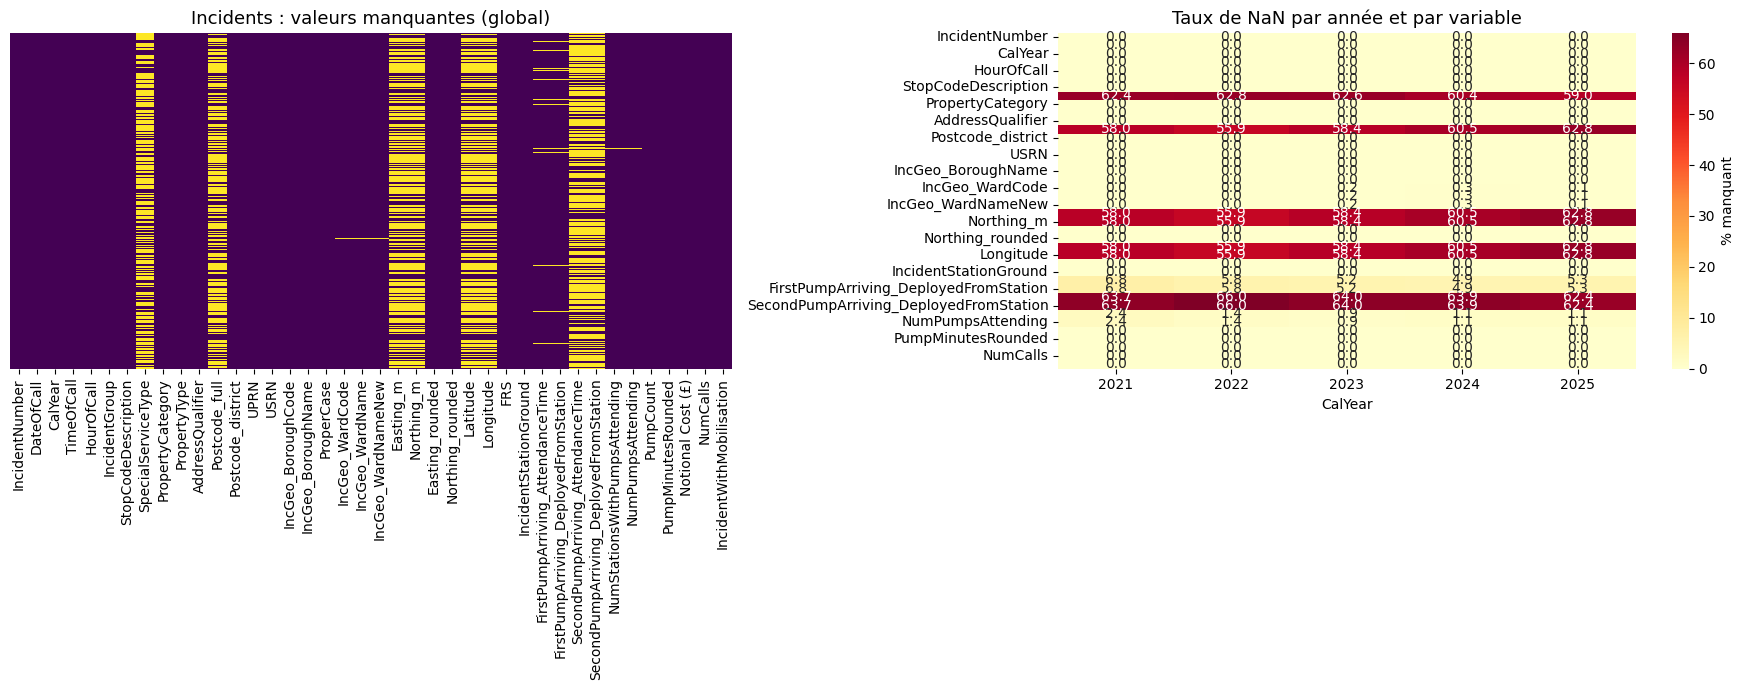

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(incident_postcovid.isna(), yticklabels=False,
            cbar=False, cmap="viridis", ax=axes[0])
axes[0].set_title("Incidents : valeurs manquantes (global)", fontsize=13)

nan_par_an = incident_postcovid.isna().groupby(
    incident_postcovid['CalYear']).mean() * 100
sns.heatmap(nan_par_an.T, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={'label': '% manquant'}, ax=axes[1])
axes[1].set_title("Taux de NaN par année et par variable", fontsize=13)

plt.tight_layout()
plt.show()

> **Décisions de traitement des NaN :**
>
> | Colonne | NaN | Décision |
> |---|---|---|
> | `SpecialServiceType` | ~388k | Fusionnée dans `StopCodeDescription` puis supprimée |
> | `Postcode_full` / `Easting_m` / `Latitude` / `Longitude` | ~375k | Supprimées (anonymisées par la LFB) |
> | `FirstPumpArriving_AttendanceTime` | ~35k | Conservée — NaN = appel sans envoi de camion |
> | `SecondPumpArriving_AttendanceTime` | ~405k | Conservée — NaN = pas de 2ème véhicule |

### 5.2 Fusion StopCodeDescription / SpecialServiceType

In [29]:
masque_special = incident_postcovid['IncidentGroup'] == 'Special Service'
incident_postcovid.loc[masque_special, 'StopCodeDescription'] = (
    incident_postcovid.loc[masque_special, 'SpecialServiceType']
)
print("✅ Fusion StopCodeDescription / SpecialServiceType effectuée")

✅ Fusion StopCodeDescription / SpecialServiceType effectuée


### 5.3 Conversion des coordonnées (British National Grid → WGS84)

Les coordonnées `Easting_rounded` / `Northing_rounded` sont en système britannique
(EPSG:27700). Conversion en latitude/longitude standard (EPSG:4326) pour Power BI.

In [30]:
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326")

def convert_to_latlon(east, north):
    """Convertit des coordonnées British National Grid en WGS84 (lat, lon)."""
    return transformer.transform(east, north)

incident_postcovid['latitude_rounded'], incident_postcovid['longitude_rounded'] = zip(
    *incident_postcovid.apply(
        lambda row: convert_to_latlon(row['Easting_rounded'], row['Northing_rounded']),
        axis=1
    )
)
print("✅ Conversion coordonnées terminée")
incident_postcovid[['Easting_rounded', 'Northing_rounded',
                     'latitude_rounded', 'longitude_rounded']].head(3)

✅ Conversion coordonnées terminée


,Easting_rounded,Northing_rounded,latitude_rounded,longitude_rounded
1297831,528750,189550,51.590099,-0.142862
1297832,540750,191750,51.607001,0.031130
1297833,549550,184550,51.540043,0.155052


### 5.4 Suppression des colonnes inutiles

✅ Colonnes restantes : 33


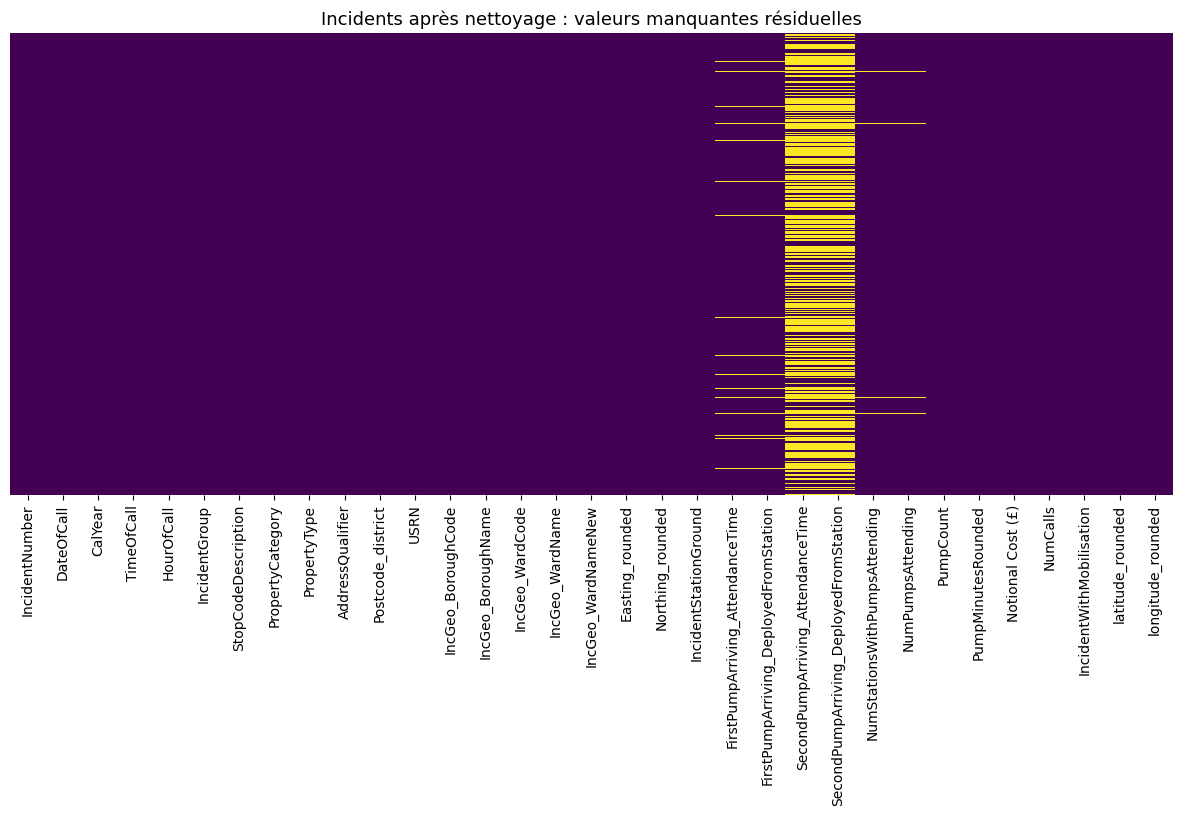

In [31]:
columns_to_drop = [
    'ProperCase',         # Doublon de IncGeo_BoroughName
    'Easting_m',          # Anonymisé par LFB (précision au mètre)
    'Northing_m',         # Anonymisé par LFB (précision au mètre)
    'FRS',                # Valeur identique sur toute la colonne
    'SpecialServiceType', # Fusionnée dans StopCodeDescription
    'Latitude',           # Anonymisée par LFB
    'Longitude',          # Anonymisée par LFB
    'UPRN',               # Anonymisé par LFB
    'Postcode_full'       # Anonymisé par LFB
]

incident_postcovid.drop(columns=columns_to_drop, inplace=True)
print(f"✅ Colonnes restantes : {incident_postcovid.shape[1]}")

plt.figure(figsize=(15, 6))
sns.heatmap(incident_postcovid.isna(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Incidents après nettoyage : valeurs manquantes résiduelles", fontsize=13)
plt.show()

## 6. Traitement des valeurs manquantes — Mobilisations

### 6.1 Visualisation & analyse des NaN

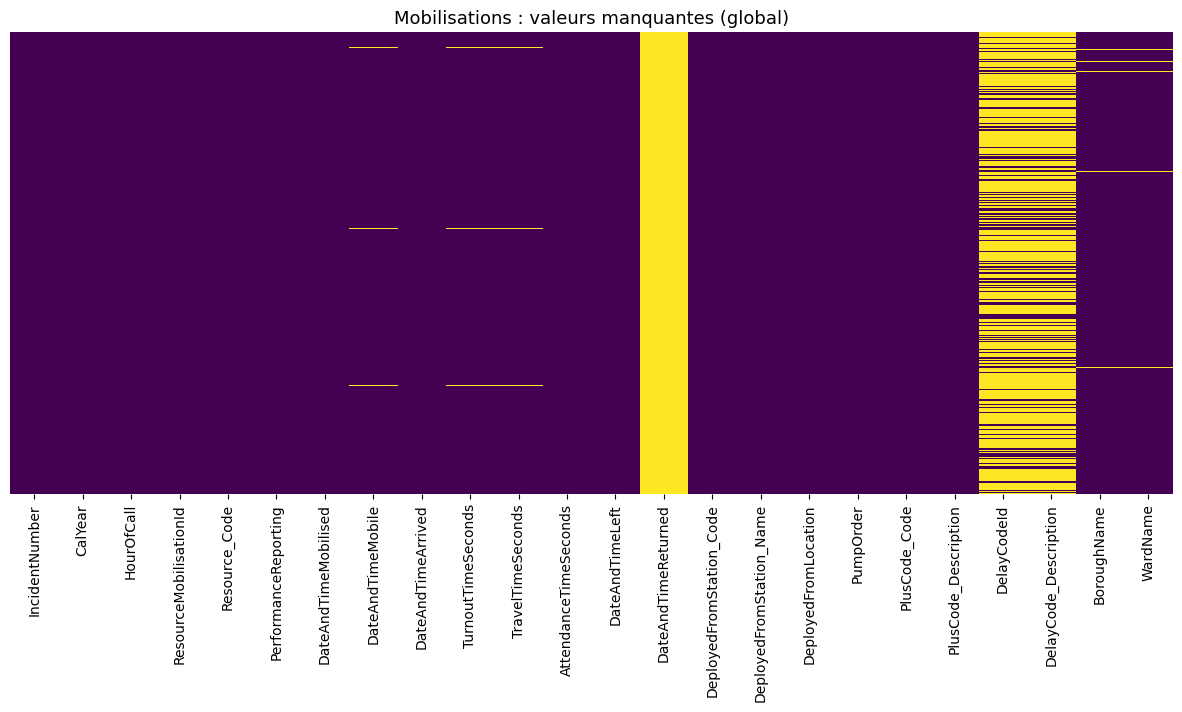

,type,nb_valeurs_uniques,nb_valeurs_nulles,pourcentage_null
PlusCode_Code,str,1,0,0.00
DateAndTimeReturned,datetime64[us],1,930520,100.00
PlusCode_Description,str,1,0,0.00
DeployedFromLocation,str,2,954,0.10
PerformanceReporting,Int64,3,0,0.00
CalYear,int64,5,0,0.00
DelayCodeId,float64,10,691159,74.28
DelayCode_Description,str,10,691159,74.28
PumpOrder,int64,13,0,0.00
HourOfCall,int64,24,0,0.00


In [32]:
plt.figure(figsize=(15, 6))
sns.heatmap(mobilisation_postcovid.isna(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Mobilisations : valeurs manquantes (global)", fontsize=13)
plt.show()

resume_df(mobilisation_postcovid)

### 6.2 Traitement de DelayCode

**Analyse :** Les NaN dans `DelayCodeId` et `DelayCode_Description` correspondent
aux mobilisations **sans retard** (temps d'arrivée < 6 min pour le véhicule 1,
< 8 min pour le véhicule 2). Point confirmé par contact direct avec la LFB.

→ Les NaN sont remplacés par des valeurs sentinelles : `-1` et `'Sans délai'`.

In [33]:
mobilisation_postcovid['DelayCodeId'] = (
    pd.to_numeric(mobilisation_postcovid['DelayCodeId'], errors='coerce')
    .fillna(-1)
    .astype('Int64')
)

mobilisation_postcovid['DelayCode_Description'] = (
    mobilisation_postcovid['DelayCode_Description']
    .astype(str)
    .replace(['nan', 'None', 'None '], 'Sans délai')
)

print("✅ DelayCode nettoyé")
mobilisation_postcovid['DelayCode_Description'].value_counts().head(10)

✅ DelayCode nettoyé


DelayCode_Description
Not held up                           149987
Traffic, roadworks, etc                51281
Traffic calming measures               17898
Address incomplete/wrong                9366
Arrived but held up - Other reason      2735
On outside duty when mobilised          2343
Mob/Radio problems when mobilised       2274
Weather conditions                      1772
Appliance/Equipment defect              1138
At drills when mobilised                 568
Name: count, dtype: int64

### 6.3 Création des indicateurs de performance légale

La LFB est soumise à des objectifs formalisés dans le **London Safety Plan** :
- 🎯 Véhicule 1 : arrivée en **≤ 6 minutes**
- 🎯 Véhicule 2 : arrivée en **≤ 8 minutes**

In [34]:
mobilisation_postcovid['is_inferieur_6_min'] = np.where(
    mobilisation_postcovid['AttendanceTimeSeconds'] <= 6 * 60, 1, 0
)
mobilisation_postcovid['is_inferieur_8_min'] = np.where(
    mobilisation_postcovid['AttendanceTimeSeconds'] <= 8 * 60, 1, 0
)

print("✅ Indicateurs légaux créés")
print(f"Taux de respect objectif 6 min : "
      f"{mobilisation_postcovid['is_inferieur_6_min'].mean()*100:.1f}%")
print(f"Taux de respect objectif 8 min : "
      f"{mobilisation_postcovid['is_inferieur_8_min'].mean()*100:.1f}%")

✅ Indicateurs légaux créés
Taux de respect objectif 6 min : 56.8%
Taux de respect objectif 8 min : 82.4%


### 6.4 Imputation des temps manquants (TurnoutTime, TravelTime, DateAndTimeMobile)

**Stratégie :** remplacement des NaN par la **moyenne de la caserne** concernée.
Si une caserne n'a aucune donnée → moyenne globale.

In [35]:
for col in ['TurnoutTimeSeconds', 'TravelTimeSeconds']:
    mobilisation_postcovid[col] = pd.to_numeric(
        mobilisation_postcovid[col], errors='coerce'
    ).astype(float)

for col in ['TurnoutTimeSeconds', 'TravelTimeSeconds']:
    mobilisation_postcovid[col] = mobilisation_postcovid[col].fillna(
        mobilisation_postcovid.groupby('DeployedFromStation_Name')[col].transform('mean')
    )
    mobilisation_postcovid[col] = mobilisation_postcovid[col].fillna(
        mobilisation_postcovid[col].mean()
    )

mobilisation_postcovid['AttendanceTimeSeconds'] = (
    mobilisation_postcovid['TurnoutTimeSeconds'] +
    mobilisation_postcovid['TravelTimeSeconds']
)

mobilisation_postcovid['DateAndTimeMobilised'] = pd.to_datetime(
    mobilisation_postcovid['DateAndTimeMobilised'])
mobilisation_postcovid['DateAndTimeMobile'] = pd.to_datetime(
    mobilisation_postcovid['DateAndTimeMobile'])

mask_nan = mobilisation_postcovid['DateAndTimeMobile'].isna()
mobilisation_postcovid.loc[mask_nan, 'DateAndTimeMobile'] = (
    mobilisation_postcovid.loc[mask_nan, 'DateAndTimeMobilised'] +
    pd.to_timedelta(
        mobilisation_postcovid.loc[mask_nan, 'TurnoutTimeSeconds'].fillna(0).round(),
        unit='s'
    )
)

for col in ['TurnoutTimeSeconds', 'TravelTimeSeconds', 'AttendanceTimeSeconds']:
    mobilisation_postcovid[col] = mobilisation_postcovid[col].round().astype('Int64')

print("✅ Imputation des temps terminée")

✅ Imputation des temps terminée


## 7. Enrichissement météo (API Open-Meteo)

Données météo horaires récupérées via l'API **Open-Meteo Historical Archive** pour
**5 zones géographiques** de Londres sur 2021–2025.

> API gratuite, sans clé requise. Documentation : https://open-meteo.com/

In [36]:
mapping_zones_codes = {
    'E09000001': 'Central', 'E09000007': 'Central', 'E09000019': 'Central',
    'E09000021': 'Central', 'E09000028': 'Central', 'E09000033': 'Central',
    'E09000003': 'North',   'E09000010': 'North',   'E09000014': 'North',
    'E09000017': 'North',   'E09000031': 'North',
    'E09000005': 'South',   'E09000008': 'South',   'E09000020': 'South',
    'E09000022': 'South',   'E09000024': 'South',   'E09000029': 'South',
    'E09000032': 'South',
    'E09000002': 'East',    'E09000004': 'East',    'E09000011': 'East',
    'E09000015': 'East',    'E09000016': 'East',    'E09000023': 'East',
    'E09000025': 'East',    'E09000026': 'East',    'E09000027': 'East',
    'E09000030': 'East',
    'E09000006': 'West',    'E09000009': 'West',    'E09000012': 'West',
    'E09000013': 'West',    'E09000018': 'West'
}
incident_postcovid['Zone'] = incident_postcovid['IncGeo_BoroughCode'].map(mapping_zones_codes)

zones_coords = {
    "Central": {"lat": 51.5074, "lon": -0.1278},
    "North":   {"lat": 51.6156, "lon": -0.1323},
    "South":   {"lat": 51.3762, "lon": -0.0982},
    "East":    {"lat": 51.5302, "lon":  0.0814},
    "West":    {"lat": 51.5042, "lon": -0.4483}
}

cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

all_weather_data = []
for zone_name, coords in zones_coords.items():
    print(f"Extraction météo : {zone_name}...")
    params = {
        "latitude": coords["lat"], "longitude": coords["lon"],
        "start_date": "2021-01-01", "end_date": "2025-12-31",
        "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation",
                   "wind_speed_10m", "wind_gusts_10m", "shortwave_radiation"],
        "timezone": "Europe/London"
    }
    responses = openmeteo.weather_api(
        "https://archive-api.open-meteo.com/v1/archive", params=params)
    res = responses[0]
    hourly = res.Hourly()
    df_temp = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()), inclusive="left"
        ),
        "temp_c": hourly.Variables(0).ValuesAsNumpy(),
        "humidity": hourly.Variables(1).ValuesAsNumpy(),
        "precip_mm": hourly.Variables(2).ValuesAsNumpy(),
        "wind_speed": hourly.Variables(3).ValuesAsNumpy(),
        "wind_gusts": hourly.Variables(4).ValuesAsNumpy(),
        "radiation": hourly.Variables(5).ValuesAsNumpy(),
        "Zone": zone_name
    })
    all_weather_data.append(df_temp)

df_weather_final = pd.concat(all_weather_data, ignore_index=True)
print(f"\n✅ Données météo : {df_weather_final.shape}")
df_weather_final.head(3)

Extraction météo : Central...
Extraction météo : North...
Extraction météo : South...
Extraction météo : East...
Extraction météo : West...

✅ Données météo : (219120, 8)


,date,temp_c,humidity,precip_mm,wind_speed,wind_gusts,radiation,Zone
0,2020-12-31 23:00:00+00:00,-1.00,95.697243,0.0,5.483356,8.64,0.0,Central
1,2021-01-01 00:00:00+00:00,-0.20,96.426018,0.0,3.758510,9.00,0.0,Central
2,2021-01-01 01:00:00+00:00,-0.75,97.474831,0.0,4.735060,7.92,0.0,Central


## 8. Exports finaux

Export des DataFrames nettoyés en `.parquet` dans `data/processed/`
pour chargement dans Power BI.

In [37]:
dossier_export = os.path.join(os.getcwd(), 'data', 'processed')
os.makedirs(dossier_export, exist_ok=True)

exports = {
    'incident_postcovid.parquet':             incident_postcovid,
    'mobilisation_postcovid.parquet':         mobilisation_postcovid,
    'london_weather_zones_2021_2025.parquet': df_weather_final
}

for nom_fichier, df in exports.items():
    chemin = os.path.join(dossier_export, nom_fichier)
    df.to_parquet(chemin, index=False)
    print(f"✅ Exporté : {nom_fichier} ({len(df):,} lignes)")

print("\n🎯 Preprocessing terminé — fichiers prêts pour Power BI")

✅ Exporté : incident_postcovid.parquet (633,178 lignes)
✅ Exporté : mobilisation_postcovid.parquet (930,521 lignes)
✅ Exporté : london_weather_zones_2021_2025.parquet (219,120 lignes)

🎯 Preprocessing terminé — fichiers prêts pour Power BI
